# Modelos de Machine Learning para la predicción del PGA

En este capítulo se aplican modelos de Machine Learning para predecir el valor de PGA aproximado mediante el periodo corto `T_0.01_RotD50`.

El objetivo no es construir una herramienta interactiva, sino comparar varios modelos bajo una misma estructura de datos, evaluar sus métricas y seleccionar el modelo con mejor desempeño predictivo.

Los modelos evaluados siguen la misma lógica del Dash:

- Regresión lineal
- XGBoost
- Random Forest
- SVR con kernel RBF
- MLP

Las variables base del problema son:

- `Magnitude`
- `Rrup_OpenQuake`
- `Hypocenter Depth (km)`
- `Soil_Class`

Además, siguiendo la lógica del Dash, se crean variables derivadas:

- `Rrup_km`
- `log_Rrup`
- `Mag_logRrup`
- `Mag2`
- `log_Depth`

La variable objetivo es:

- `T_0.01_RotD50`

En este Jupyter Book, `T_0.01_RotD50` ya se encuentra en escala logarítmica, por lo que se modela directamente como `ln(PGA)`.

También se verificó que `Rrup_OpenQuake` ya viene como `ln(Rrup)`. Por tanto, no se vuelve a aplicar logaritmo sobre esa columna. Para recuperar la distancia en kilómetros se usa:

\[
Rrup_{km} = \exp(Rrup\_OpenQuake)
\]

La columna `Tmax` se utiliza como máscara de confiabilidad espectral. Para este capítulo solo se usan registros con:

\[
T_{max} \geq 0.01
\]

Esto permite usar únicamente registros donde el periodo `T = 0.01 s` se encuentra dentro del rango confiable del espectro.

In [1]:
# =========================================================
# BLOQUE 1. LIBRERÍAS Y CONFIGURACIÓN GENERAL
# =========================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

try:
    from xgboost import XGBRegressor
except Exception as exc:
    XGBRegressor = None
    print("XGBoost no está disponible. Instala xgboost para replicar completamente el Dash.")
    print(f"Detalle: {exc}")

warnings.filterwarnings("ignore")

# -------------------------------
# Configuración reproducible
# -------------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_SPLITS = 5

# -------------------------------
# Variable objetivo
# -------------------------------
TARGET = "T_0.01_RotD50"
TARGET_PERIOD = 0.01

# -------------------------------
# Columna de máscara espectral
# -------------------------------
TMAX_CANDIDATES = ["Tmax", "T_max", "TMAX", "tmax"]

# -------------------------------
# Variables base del problema
# -------------------------------
BASE_FEATURES = [
    "Magnitude",
    "Rrup_OpenQuake",
    "Hypocenter Depth (km)",
    "Soil_Class",
]

# ---------------------------------------------------------
# IMPORTANTE SOBRE ESCALA:
#
# En el Dash:
# - Rrup_OpenQuake estaba en km.
# - Se calculaba log_Rrup = log(Rrup_OpenQuake).
#
# En este Jupyter Book:
# - Rrup_OpenQuake ya está como ln(Rrup).
#
# Por tanto:
# - Rrup_km = exp(Rrup_OpenQuake)
# - log_Rrup = Rrup_OpenQuake
#
# Esto evita aplicar logaritmo dos veces.
# ---------------------------------------------------------

NUMERIC_FEATURES = [
    "Magnitude",
    "Rrup_km",
    "Hypocenter Depth (km)",
    "log_Rrup",
    "Mag_logRrup",
    "Mag2",
    "log_Depth",
]

CATEGORICAL_FEATURES = ["Soil_Class"]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

print("Configuración cargada correctamente.")

Configuración cargada correctamente.


In [2]:
# =========================================================
# BLOQUE 2. CARGA DEL DATASET
# =========================================================

possible_paths = [
    Path("NGACOL.csv"),
    Path("docs/NGACOL.csv"),
    Path("../docs/NGACOL.csv"),
    Path.cwd() / "NGACOL.csv",
    Path.cwd() / "docs" / "NGACOL.csv",
]

data_path = None

for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "No se encontró NGACOL.csv. Verifica que esté dentro de la carpeta docs/."
    )

df_raw = pd.read_csv(data_path)

print(f"Archivo cargado: {data_path.resolve()}")
print(f"Dimensiones originales: {df_raw.shape[0]:,} filas x {df_raw.shape[1]:,} columnas")

display(df_raw.head())

Archivo cargado: C:\Users\elias\OneDrive\Desktop\dataviz_py\eda-jbook\docs\NGACOL.csv
Dimensiones originales: 10,239 filas x 11 columnas


,Hypocenter Depth (km),Magnitude,Rrup_OpenQuake,Soil_Class,Tmax,origen,Seismic Latitude,Seismic Longitude,Station Latitude,Station Longitude,T_0.01_RotD50
0,7.213,3.4,2.503074,2,0.808081,NGAW2,37.1173,-121.5231,37.1635,-121.6265,-6.819442
1,7.213,3.4,3.296947,3,1.081081,NGAW2,37.1173,-121.5231,37.0492,-121.8072,-6.369086
2,7.213,3.4,3.551053,3,1.081081,NGAW2,37.1173,-121.5231,36.9275,-121.8276,-5.961014
3,7.213,3.4,2.999226,3,1.333333,NGAW2,37.1173,-121.5231,37.1543,-121.7347,-5.323799
4,8.469,3.4,2.526528,3,1.666667,NGAW2,36.6008,-121.2089,36.6181,-121.3147,-2.696168


In [3]:
# =========================================================
# BLOQUE 3. VERIFICACIÓN DE COLUMNAS NECESARIAS
# =========================================================

if TARGET not in df_raw.columns:
    raise ValueError(f"No se encontró la variable objetivo: {TARGET}")

tmax_col = None

for col in TMAX_CANDIDATES:
    if col in df_raw.columns:
        tmax_col = col
        break

if tmax_col is None:
    raise ValueError(
        f"No se encontró columna de T_max. Se buscaron estas opciones: {TMAX_CANDIDATES}"
    )

missing_base = [c for c in BASE_FEATURES if c not in df_raw.columns]

if missing_base:
    raise ValueError(f"Faltan variables base en el dataset: {missing_base}")

print(f"Variable objetivo detectada: {TARGET}")
print(f"Columna de máscara detectada: {tmax_col}")
print("Variables base encontradas correctamente:")
print(BASE_FEATURES)

Variable objetivo detectada: T_0.01_RotD50
Columna de máscara detectada: Tmax
Variables base encontradas correctamente:
['Magnitude', 'Rrup_OpenQuake', 'Hypocenter Depth (km)', 'Soil_Class']


In [4]:
# =========================================================
# BLOQUE 4. VERIFICACIÓN INICIAL DE ESCALAS DEL BOOK
# =========================================================

scale_preview = df_raw[[TARGET, "Rrup_OpenQuake", tmax_col]].copy()

for col in [TARGET, "Rrup_OpenQuake", tmax_col]:
    scale_preview[col] = pd.to_numeric(scale_preview[col], errors="coerce")

scale_summary = pd.DataFrame({
    "Variable": [TARGET, "Rrup_OpenQuake", tmax_col],
    "Mínimo": [
        scale_preview[TARGET].min(),
        scale_preview["Rrup_OpenQuake"].min(),
        scale_preview[tmax_col].min(),
    ],
    "Mediana": [
        scale_preview[TARGET].median(),
        scale_preview["Rrup_OpenQuake"].median(),
        scale_preview[tmax_col].median(),
    ],
    "Máximo": [
        scale_preview[TARGET].max(),
        scale_preview["Rrup_OpenQuake"].max(),
        scale_preview[tmax_col].max(),
    ],
    "% valores negativos": [
        100 * (scale_preview[TARGET] < 0).mean(),
        100 * (scale_preview["Rrup_OpenQuake"] < 0).mean(),
        100 * (scale_preview[tmax_col] < 0).mean(),
    ],
})

display(scale_summary.round(4))

display(Markdown(f"""
### Lectura de escalas

En este Jupyter Book, `{TARGET}` se interpreta como `ln(PGA)` porque la mayoría de sus valores son negativos.

La columna `Rrup_OpenQuake` se interpreta como `ln(Rrup)`. Por tanto, para recuperar la distancia en kilómetros se usa:

`Rrup_km = exp(Rrup_OpenQuake)`

Esta decisión es importante porque en el Dash `Rrup_OpenQuake` estaba en kilómetros, mientras que en este book ya viene transformada.
"""))

,Variable,Mínimo,Mediana,Máximo,% valores negativos
0,T_0.01_RotD50,-9.0896,-4.0768,0.5840,99.8633
1,Rrup_OpenQuake,-2.9957,4.2694,7.3348,0.1660
2,Tmax,0.0949,8.8889,133.3333,0.0000



### Lectura de escalas

En este Jupyter Book, `T_0.01_RotD50` se interpreta como `ln(PGA)` porque la mayoría de sus valores son negativos.

La columna `Rrup_OpenQuake` se interpreta como `ln(Rrup)`. Por tanto, para recuperar la distancia en kilómetros se usa:

`Rrup_km = exp(Rrup_OpenQuake)`

Esta decisión es importante porque en el Dash `Rrup_OpenQuake` estaba en kilómetros, mientras que en este book ya viene transformada.


In [5]:
# =========================================================
# BLOQUE 5. LIMPIEZA E INGENIERÍA DE VARIABLES SEGÚN EL JBOOK
# =========================================================

def engineer_features_jbook(df):
    """
    Ingeniería de variables adaptada al Jupyter Book.

    En el Dash:
    - Rrup_OpenQuake = Rrup en km.
    - log_Rrup = log(Rrup_OpenQuake).

    En este Jupyter Book:
    - Rrup_OpenQuake ya es ln(Rrup).
    - Por tanto, NO se calcula log(Rrup_OpenQuake).

    Se crea:
    - Rrup_km = exp(Rrup_OpenQuake)
    - log_Rrup = Rrup_OpenQuake
    - Mag_logRrup = Magnitude - log_Rrup
    - Mag2 = Magnitude^2
    - log_Depth = log(Hypocenter Depth)
    """

    df = df.copy()

    # -------------------------------
    # Limpieza de Soil_Class
    # -------------------------------
    df["Soil_Class"] = (
        df["Soil_Class"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.strip()
    )

    # -------------------------------
    # Conversión numérica
    # -------------------------------
    numeric_cols = [
        "Magnitude",
        "Rrup_OpenQuake",
        "Hypocenter Depth (km)",
        TARGET,
        tmax_col,
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # -------------------------------
    # Adaptación de escala de Rrup
    # -------------------------------
    df["Rrup_km"] = np.exp(df["Rrup_OpenQuake"])

    # En el book, Rrup_OpenQuake ya es ln(Rrup)
    df["log_Rrup"] = df["Rrup_OpenQuake"]

    # -------------------------------
    # Variables derivadas equivalentes al Dash
    # -------------------------------
    df["Mag_logRrup"] = df["Magnitude"] - df["log_Rrup"]
    df["Mag2"] = df["Magnitude"] ** 2
    df["log_Depth"] = np.log(df["Hypocenter Depth (km)"].clip(lower=1e-6))

    return df


df = df_raw.copy()

# -------------------------------
# Aplicar máscara de confiabilidad espectral
# -------------------------------
df = df.loc[df[tmax_col] >= TARGET_PERIOD].copy()

# -------------------------------
# Ingeniería de variables
# -------------------------------
df = engineer_features_jbook(df)

# -------------------------------
# Limpieza final
# -------------------------------
df_model = df.dropna(subset=ALL_FEATURES + [TARGET]).copy()

print(f"Registros originales: {len(df_raw):,}")
print(f"Registros después de aplicar {tmax_col} >= {TARGET_PERIOD}: {len(df):,}")
print(f"Registros después de limpieza final: {len(df_model):,}")

display(
    df_model[
        [
            "Magnitude",
            "Rrup_OpenQuake",
            "Rrup_km",
            "log_Rrup",
            "Hypocenter Depth (km)",
            "Mag_logRrup",
            "Mag2",
            "log_Depth",
            "Soil_Class",
            TARGET,
            tmax_col,
        ]
    ].head()
)

Registros originales: 10,239
Registros después de aplicar Tmax >= 0.01: 10,204
Registros después de limpieza final: 10,204


,Magnitude,Rrup_OpenQuake,Rrup_km,log_Rrup,Hypocenter Depth (km),Mag_logRrup,Mag2,log_Depth,Soil_Class,T_0.01_RotD50,Tmax
0,3.4,2.503074,12.22,2.503074,7.213,0.896926,11.56,1.975885,2,-6.819442,0.808081
1,3.4,3.296947,27.03,3.296947,7.213,0.103053,11.56,1.975885,3,-6.369086,1.081081
2,3.4,3.551053,34.85,3.551053,7.213,-0.151053,11.56,1.975885,3,-5.961014,1.081081
3,3.4,2.999226,20.07,2.999226,7.213,0.400774,11.56,1.975885,3,-5.323799,1.333333
4,3.4,2.526528,12.51,2.526528,8.469,0.873472,11.56,2.136412,3,-2.696168,1.666667


In [6]:
# =========================================================
# BLOQUE 6. VERIFICACIÓN FINAL DE ESCALAS USADAS
# =========================================================

final_scale_check = pd.DataFrame({
    "Variable": [
        "Rrup_OpenQuake original",
        "Rrup_km = exp(Rrup_OpenQuake)",
        "log_Rrup usado por el modelo",
        TARGET,
    ],
    "Interpretación": [
        "ln(Rrup)",
        "Rrup en km",
        "ln(Rrup)",
        "ln(PGA)",
    ],
    "Mínimo": [
        df_model["Rrup_OpenQuake"].min(),
        df_model["Rrup_km"].min(),
        df_model["log_Rrup"].min(),
        df_model[TARGET].min(),
    ],
    "Mediana": [
        df_model["Rrup_OpenQuake"].median(),
        df_model["Rrup_km"].median(),
        df_model["log_Rrup"].median(),
        df_model[TARGET].median(),
    ],
    "Máximo": [
        df_model["Rrup_OpenQuake"].max(),
        df_model["Rrup_km"].max(),
        df_model["log_Rrup"].max(),
        df_model[TARGET].max(),
    ],
})

display(final_scale_check.round(4))

,Variable,Interpretación,Mínimo,Mediana,Máximo
0,Rrup_OpenQuake original,ln(Rrup),-2.9957,4.2693,7.3348
1,Rrup_km = exp(Rrup_OpenQuake),Rrup en km,0.0500,71.4750,1532.6600
2,log_Rrup usado por el modelo,ln(Rrup),-2.9957,4.2693,7.3348
3,T_0.01_RotD50,ln(PGA),-9.0896,-4.0843,0.5840


In [7]:
# =========================================================
# BLOQUE 7. DEFINICIÓN DE X E y
# =========================================================

X = df_model[ALL_FEATURES].copy()

y_raw = df_model[TARGET].astype(float)

# En el JBook, la variable objetivo ya parece estar en ln(PGA)
TARGET_ALREADY_LOG = (y_raw < 0).mean() > 0.50

if TARGET_ALREADY_LOG:
    y = y_raw.copy()
    target_scale_message = "La variable objetivo ya está en escala logarítmica: ln(PGA)."
else:
    y = np.log(y_raw.clip(lower=1e-12))
    target_scale_message = "La variable objetivo estaba en escala original y fue transformada a ln(PGA)."

print(target_scale_message)
print(f"Porcentaje de valores negativos en {TARGET}: {(y_raw < 0).mean() * 100:.2f}%")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

display(X.head())

La variable objetivo ya está en escala logarítmica: ln(PGA).
Porcentaje de valores negativos en T_0.01_RotD50: 99.86%
X shape: (10204, 8)
y shape: (10204,)


,Magnitude,Rrup_km,Hypocenter Depth (km),log_Rrup,Mag_logRrup,Mag2,log_Depth,Soil_Class
0,3.4,12.22,7.213,2.503074,0.896926,11.56,1.975885,2
1,3.4,27.03,7.213,3.296947,0.103053,11.56,1.975885,3
2,3.4,34.85,7.213,3.551053,-0.151053,11.56,1.975885,3
3,3.4,20.07,7.213,2.999226,0.400774,11.56,1.975885,3
4,3.4,12.51,8.469,2.526528,0.873472,11.56,2.136412,3


In [8]:
# =========================================================
# BLOQUE 8. RESUMEN DEL DATASET DE MODELADO
# =========================================================

summary_table = pd.DataFrame({
    "Elemento": [
        "Registros usados",
        "Variable objetivo",
        "Escala objetivo",
        "Periodo objetivo",
        "Máscara aplicada",
        "Magnitud mínima",
        "Magnitud máxima",
        "Rrup mínimo aproximado (km)",
        "Rrup máximo aproximado (km)",
        "Clases de suelo",
    ],
    "Valor": [
        f"{len(df_model):,}",
        TARGET,
        "ln(PGA)",
        f"{TARGET_PERIOD} s",
        f"{tmax_col} >= {TARGET_PERIOD}",
        round(df_model["Magnitude"].min(), 3),
        round(df_model["Magnitude"].max(), 3),
        round(df_model["Rrup_km"].min(), 3),
        round(df_model["Rrup_km"].max(), 3),
        ", ".join(sorted(df_model["Soil_Class"].dropna().unique())),
    ]
})

display(summary_table)

,Elemento,Valor
0,Registros usados,"10,204"
1,Variable objetivo,T_0.01_RotD50
2,Escala objetivo,ln(PGA)
3,Periodo objetivo,0.01 s
4,Máscara aplicada,Tmax >= 0.01
5,Magnitud mínima,3.2
6,Magnitud máxima,7.9
7,Rrup mínimo aproximado (km),0.05
8,Rrup máximo aproximado (km),1532.66
9,Clases de suelo,"1, 2, 3, 4, 5"


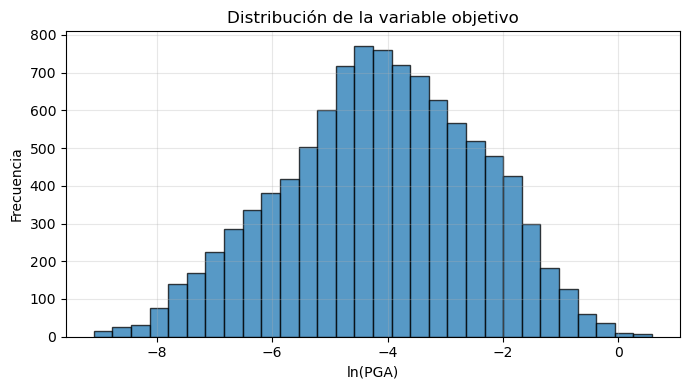

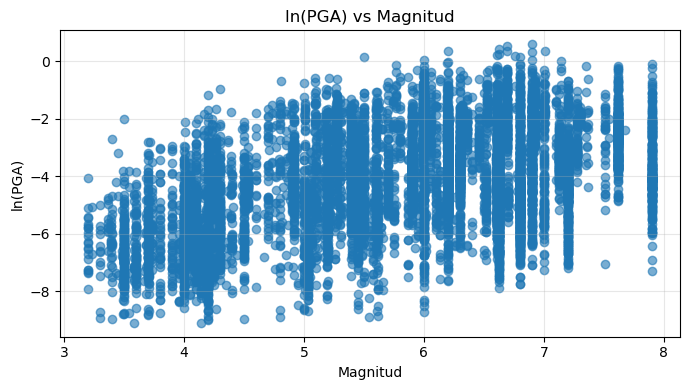

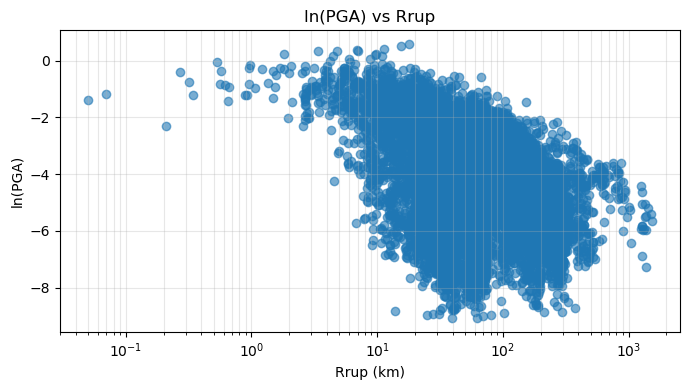

In [9]:
# =========================================================
# BLOQUE 9. GRÁFICAS EXPLORATORIAS BÁSICAS
# =========================================================

plt.figure(figsize=(7, 4))
plt.hist(y, bins=30, edgecolor="black", alpha=0.75)
plt.xlabel("ln(PGA)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(df_model["Magnitude"], y, alpha=0.6)
plt.xlabel("Magnitud")
plt.ylabel("ln(PGA)")
plt.title("ln(PGA) vs Magnitud")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(df_model["Rrup_km"], y, alpha=0.6)
plt.xscale("log")
plt.xlabel("Rrup (km)")
plt.ylabel("ln(PGA)")
plt.title("ln(PGA) vs Rrup")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# =========================================================
# BLOQUE 10. DIVISIÓN TRAIN/TEST
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):,} registros")
print(f"Test : {len(X_test):,} registros")

Train: 8,163 registros
Test : 2,041 registros


In [11]:
# =========================================================
# BLOQUE 11. PREPROCESAMIENTO
# =========================================================

def make_ohe():
    """
    Crea un OneHotEncoder compatible con diferentes versiones de scikit-learn.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(scale_numeric):
    """
    Construye el preprocesador:
    - Numéricas: escaladas o sin transformar.
    - Soil_Class: One-Hot Encoding.
    """

    if scale_numeric:
        num_transformer = Pipeline([
            ("scaler", StandardScaler())
        ])
    else:
        num_transformer = "passthrough"

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_transformer, NUMERIC_FEATURES),
            ("cat", make_ohe(), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

    return preprocessor


print("Preprocesador definido correctamente.")

Preprocesador definido correctamente.


In [12]:
# =========================================================
# BLOQUE 12. MODELOS DEL DASH
# =========================================================

def get_model_specs():
    """
    Define únicamente los modelos utilizados en el Dash:
    - Regresión lineal
    - XGBoost
    - Random Forest
    - SVR RBF
    - MLP
    """

    if XGBRegressor is None:
        raise ImportError(
            "XGBoost no está instalado. Agrega xgboost al requirements.txt "
            "o instala el paquete antes de ejecutar este capítulo."
        )

    return {
        "linear_regression": {
            "display_name": "Regresión lineal",
            "scale_numeric": True,
            "estimator": LinearRegression(),
        },

        "xgboost": {
            "display_name": "XGBoost",
            "scale_numeric": False,
            "estimator": XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                n_estimators=500,
                learning_rate=0.04,
                max_depth=4,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.0,
                reg_lambda=1.0,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },

        "random_forest": {
            "display_name": "Random Forest",
            "scale_numeric": False,
            "estimator": RandomForestRegressor(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        },

        "svr_rbf": {
            "display_name": "SVR (RBF)",
            "scale_numeric": True,
            "estimator": SVR(
                kernel="rbf",
                C=10.0,
                epsilon=0.05,
                gamma="scale",
            ),
        },

        "mlp": {
            "display_name": "MLP",
            "scale_numeric": True,
            "estimator": MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-3,
                learning_rate_init=1e-3,
                max_iter=1200,
                early_stopping=True,
                random_state=RANDOM_STATE,
            ),
        },
    }


model_specs = get_model_specs()

print("Modelos definidos según el Dash:")
for key, spec in model_specs.items():
    print(f"- {key}: {spec['display_name']}")

Modelos definidos según el Dash:
- linear_regression: Regresión lineal
- xgboost: XGBoost
- random_forest: Random Forest
- svr_rbf: SVR (RBF)
- mlp: MLP


In [13]:
# =========================================================
# BLOQUE 13. CONSTRUCCIÓN DEL PIPELINE
# =========================================================

def build_pipeline(model_key):
    """
    Construye pipeline completo:
    preprocesamiento + modelo.
    """

    spec = model_specs[model_key]

    pipeline = Pipeline([
        ("prep", build_preprocessor(scale_numeric=spec["scale_numeric"])),
        ("model", clone(spec["estimator"])),
    ])

    return pipeline


print("Función de pipeline lista.")

Función de pipeline lista.


In [14]:
# =========================================================
# BLOQUE 14. FUNCIONES DE MÉTRICAS
# =========================================================

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def compute_metrics(y_true, y_pred):
    """
    Métricas en escala ln(PGA).
    """

    return {
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def compute_original_scale_metrics(y_true_log, y_pred_log):
    """
    Métricas aproximadas en escala original PGA(g).
    """

    y_true_g = np.exp(y_true_log)
    y_pred_g = np.exp(y_pred_log)

    return {
        "rmse_g": rmse(y_true_g, y_pred_g),
        "mae_g": float(mean_absolute_error(y_true_g, y_pred_g)),
        "r2_g": float(r2_score(y_true_g, y_pred_g)),
    }


print("Funciones de métricas listas.")

Funciones de métricas listas.


In [15]:
# =========================================================
# BLOQUE 15. ENTRENAMIENTO Y EVALUACIÓN DE MODELOS
# =========================================================

cv = KFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fitted_pipelines = {}
models_meta = {}
rows = []

for model_key, spec in model_specs.items():

    model_name = spec["display_name"]
    print(f"Entrenando {model_name}...")

    pipeline = build_pipeline(model_key)

    # -------------------------------
    # Entrenamiento
    # -------------------------------
    pipeline.fit(X_train, y_train)

    # -------------------------------
    # Predicción en test
    # -------------------------------
    y_pred = pipeline.predict(X_test)

    # -------------------------------
    # Validación cruzada R2 como en el Dash
    # -------------------------------
    r2_cv5 = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="r2",
        n_jobs=1,
    ).mean()

    # -------------------------------
    # Métricas en escala logarítmica
    # -------------------------------
    metrics_log = compute_metrics(y_test, y_pred)

    # -------------------------------
    # Métricas en escala original aproximada
    # -------------------------------
    metrics_g = compute_original_scale_metrics(y_test, y_pred)

    # -------------------------------
    # Residuos
    # -------------------------------
    residuals = np.asarray(y_test) - np.asarray(y_pred)

    row = {
        "model_key": model_key,
        "display_name": model_name,

        "rmse": metrics_log["rmse"],
        "mae": metrics_log["mae"],
        "r2": metrics_log["r2"],
        "r2_cv5": float(r2_cv5),

        "rmse_g": metrics_g["rmse_g"],
        "mae_g": metrics_g["mae_g"],
        "r2_g": metrics_g["r2_g"],

        "bias_log": float(np.mean(residuals)),
        "sd_residual_log": float(np.std(residuals, ddof=1)),
    }

    rows.append(row)

    models_meta[model_key] = {
        "display_name": model_name,
        "metrics": row,
        "y_test": np.asarray(y_test).tolist(),
        "y_pred": np.asarray(y_pred).tolist(),
    }

    fitted_pipelines[model_key] = pipeline

comparison_df = pd.DataFrame(rows)

display(comparison_df.round(4))

Entrenando Regresión lineal...
Entrenando XGBoost...
Entrenando Random Forest...
Entrenando SVR (RBF)...
Entrenando MLP...


,model_key,display_name,rmse,mae,r2,r2_cv5,rmse_g,mae_g,r2_g,bias_log,sd_residual_log
0,linear_regression,Regresión lineal,0.8447,0.6506,0.7542,0.7552,2.2975,0.1441,-394.8685,0.0185,0.8447
1,xgboost,XGBoost,0.6414,0.4975,0.8583,0.8579,0.0714,0.0246,0.6175,0.0092,0.6415
2,random_forest,Random Forest,0.6731,0.5190,0.8439,0.8429,0.0716,0.0254,0.6159,0.0148,0.6731
3,svr_rbf,SVR (RBF),0.6954,0.5375,0.8334,0.8294,0.0740,0.0256,0.5892,0.0104,0.6955
4,mlp,MLP,0.6798,0.5305,0.8408,0.8335,0.0776,0.0261,0.5479,0.0315,0.6792


In [16]:
# =========================================================
# BLOQUE 16. RANKING DE MODELOS
# =========================================================

comparison_df["rank_rmse"] = comparison_df["rmse"].rank(
    method="min",
    ascending=True
)

comparison_df["rank_mae"] = comparison_df["mae"].rank(
    method="min",
    ascending=True
)

comparison_df["rank_r2"] = comparison_df["r2"].rank(
    method="min",
    ascending=False
)

comparison_df["rank_r2_cv5"] = comparison_df["r2_cv5"].rank(
    method="min",
    ascending=False
)

comparison_df["rank_mean"] = comparison_df[
    ["rank_rmse", "rank_mae", "rank_r2", "rank_r2_cv5"]
].mean(axis=1)

comparison_df = comparison_df.sort_values(
    by=["rank_mean", "rank_rmse", "rank_mae", "r2"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

comparison_df["overall_position"] = np.arange(1, len(comparison_df) + 1)

ranking_cols = [
    "overall_position",
    "display_name",
    "rmse",
    "mae",
    "r2",
    "r2_cv5",
    "rmse_g",
    "mae_g",
    "bias_log",
    "sd_residual_log",
    "rank_mean",
]

display(comparison_df[ranking_cols].round(4))

best_row = comparison_df.iloc[0]
best_model_key = best_row["model_key"]
best_model_name = best_row["display_name"]
best_model = fitted_pipelines[best_model_key]

print(f"Mejor modelo seleccionado: {best_model_name}")

,overall_position,display_name,rmse,mae,r2,r2_cv5,rmse_g,mae_g,bias_log,sd_residual_log,rank_mean
0,1,XGBoost,0.6414,0.4975,0.8583,0.8579,0.0714,0.0246,0.0092,0.6415,1.0
1,2,Random Forest,0.6731,0.5190,0.8439,0.8429,0.0716,0.0254,0.0148,0.6731,2.0
2,3,MLP,0.6798,0.5305,0.8408,0.8335,0.0776,0.0261,0.0315,0.6792,3.0
3,4,SVR (RBF),0.6954,0.5375,0.8334,0.8294,0.0740,0.0256,0.0104,0.6955,4.0
4,5,Regresión lineal,0.8447,0.6506,0.7542,0.7552,2.2975,0.1441,0.0185,0.8447,5.0


Mejor modelo seleccionado: XGBoost


In [17]:
# =========================================================
# BLOQUE 17. RESUMEN DEL MEJOR MODELO
# =========================================================

display(Markdown(f"""
## Mejor modelo seleccionado: **{best_model_name}**

El modelo con mejor desempeño global fue **{best_model_name}**.

La selección se realizó siguiendo la lógica del Dash, mediante un ranking promedio calculado a partir de:

- RMSE
- MAE
- R² en test
- R² promedio en validación cruzada de 5 particiones

### Métricas principales del mejor modelo

| Métrica | Valor |
|---|---:|
| RMSE en ln(PGA) | {best_row["rmse"]:.4f} |
| MAE en ln(PGA) | {best_row["mae"]:.4f} |
| R² en test | {best_row["r2"]:.4f} |
| R² CV5 | {best_row["r2_cv5"]:.4f} |
| RMSE aproximado en PGA(g) | {best_row["rmse_g"]:.4f} |
| MAE aproximado en PGA(g) | {best_row["mae_g"]:.4f} |
| Bias de residuos log | {best_row["bias_log"]:.4f} |
| SD de residuos log | {best_row["sd_residual_log"]:.4f} |
| Ranking promedio | {best_row["rank_mean"]:.4f} |
"""))


## Mejor modelo seleccionado: **XGBoost**

El modelo con mejor desempeño global fue **XGBoost**.

La selección se realizó siguiendo la lógica del Dash, mediante un ranking promedio calculado a partir de:

- RMSE
- MAE
- R² en test
- R² promedio en validación cruzada de 5 particiones

### Métricas principales del mejor modelo

| Métrica | Valor |
|---|---:|
| RMSE en ln(PGA) | 0.6414 |
| MAE en ln(PGA) | 0.4975 |
| R² en test | 0.8583 |
| R² CV5 | 0.8579 |
| RMSE aproximado en PGA(g) | 0.0714 |
| MAE aproximado en PGA(g) | 0.0246 |
| Bias de residuos log | 0.0092 |
| SD de residuos log | 0.6415 |
| Ranking promedio | 1.0000 |


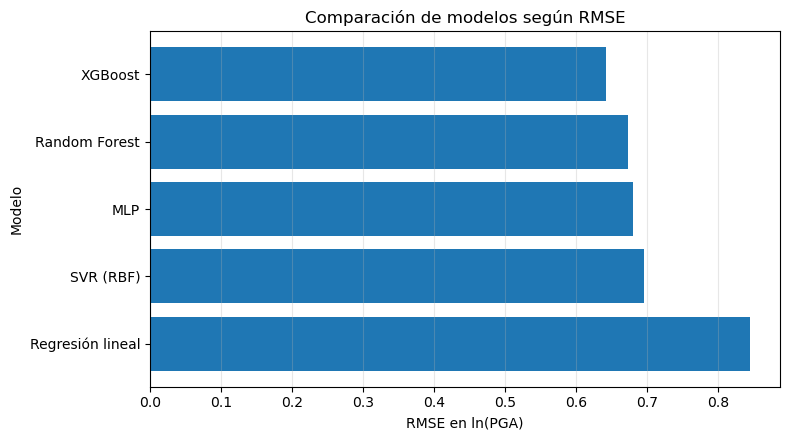

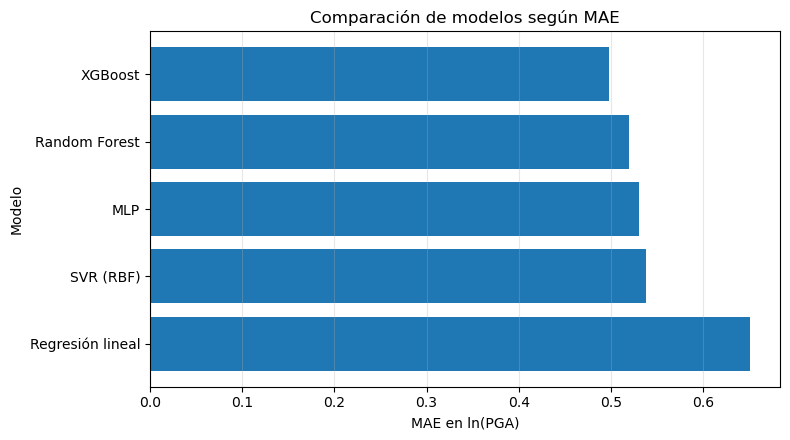

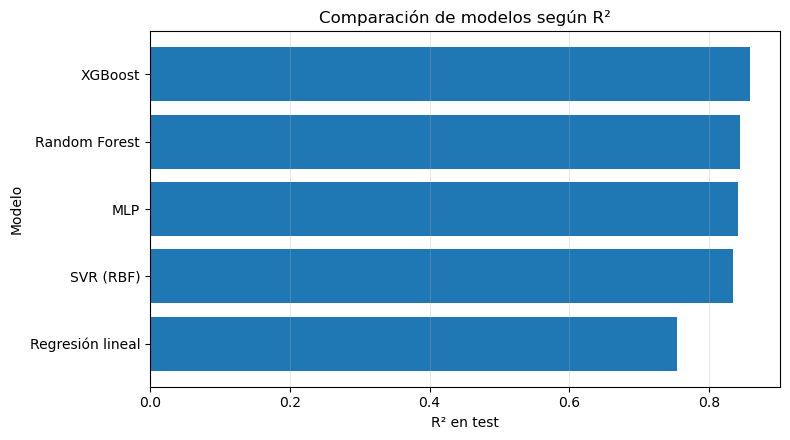

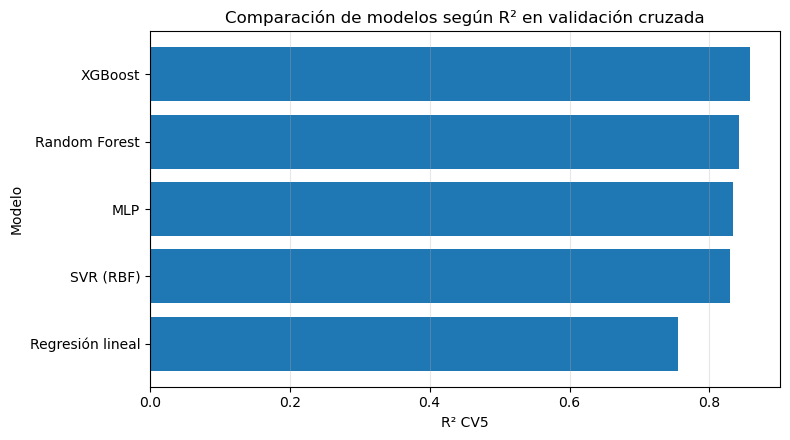

In [18]:
# =========================================================
# BLOQUE 18. COMPARACIÓN VISUAL DE MODELOS
# =========================================================

plot_df = comparison_df.sort_values("rmse", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["display_name"], plot_df["rmse"])
plt.xlabel("RMSE en ln(PGA)")
plt.ylabel("Modelo")
plt.title("Comparación de modelos según RMSE")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plot_df = comparison_df.sort_values("mae", ascending=True)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["display_name"], plot_df["mae"])
plt.xlabel("MAE en ln(PGA)")
plt.ylabel("Modelo")
plt.title("Comparación de modelos según MAE")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plot_df = comparison_df.sort_values("r2", ascending=False)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["display_name"], plot_df["r2"])
plt.xlabel("R² en test")
plt.ylabel("Modelo")
plt.title("Comparación de modelos según R²")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plot_df = comparison_df.sort_values("r2_cv5", ascending=False)

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["display_name"], plot_df["r2_cv5"])
plt.xlabel("R² CV5")
plt.ylabel("Modelo")
plt.title("Comparación de modelos según R² en validación cruzada")
plt.gca().invert_yaxis()
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

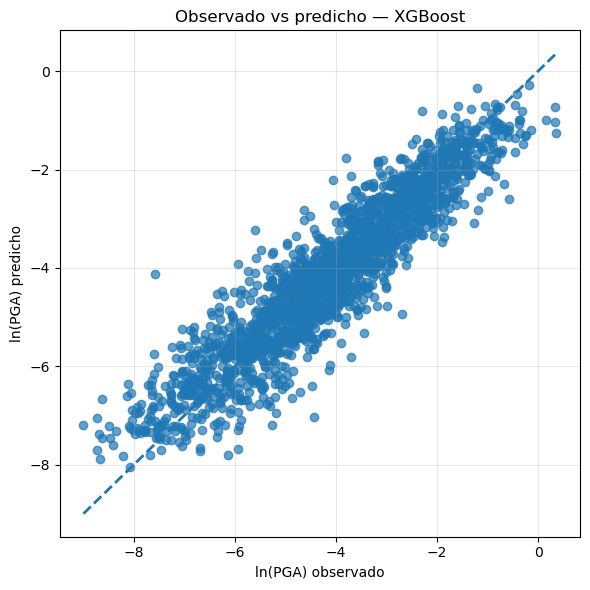

In [19]:
# =========================================================
# BLOQUE 19. OBSERVADO VS PREDICHO DEL MEJOR MODELO
# =========================================================

best_meta = models_meta[best_model_key]

y_test_best = np.asarray(best_meta["y_test"])
y_pred_best = np.asarray(best_meta["y_pred"])

min_val = min(y_test_best.min(), y_pred_best.min())
max_val = max(y_test_best.max(), y_pred_best.max())

plt.figure(figsize=(6, 6))
plt.scatter(y_test_best, y_pred_best, alpha=0.7)
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=2)
plt.xlabel("ln(PGA) observado")
plt.ylabel("ln(PGA) predicho")
plt.title(f"Observado vs predicho — {best_model_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

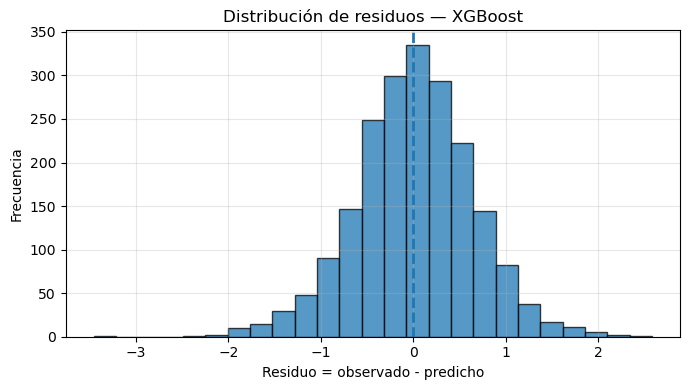

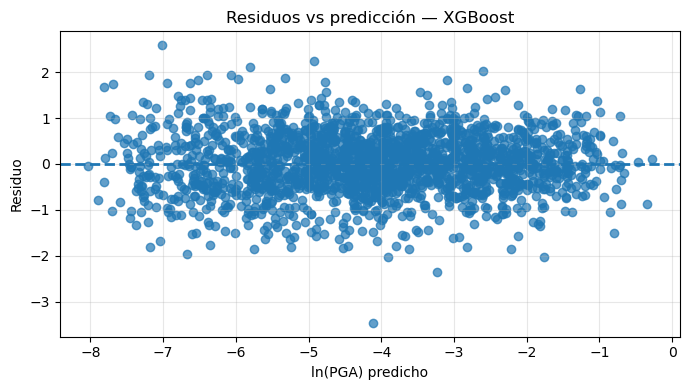

,Métrica,Valor
0,Media del residuo,0.0092
1,Mediana del residuo,0.0093
2,Desviación estándar,0.6415
3,Mínimo,-3.4555
4,Máximo,2.5836


In [20]:
# =========================================================
# BLOQUE 20. ANÁLISIS DE RESIDUOS DEL MEJOR MODELO
# =========================================================

residuals_best = y_test_best - y_pred_best

plt.figure(figsize=(7, 4))
plt.hist(residuals_best, bins=25, edgecolor="black", alpha=0.75)
plt.axvline(0, linestyle="--", linewidth=2)
plt.xlabel("Residuo = observado - predicho")
plt.ylabel("Frecuencia")
plt.title(f"Distribución de residuos — {best_model_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_best, residuals_best, alpha=0.7)
plt.axhline(0, linestyle="--", linewidth=2)
plt.xlabel("ln(PGA) predicho")
plt.ylabel("Residuo")
plt.title(f"Residuos vs predicción — {best_model_name}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

residual_summary = pd.DataFrame({
    "Métrica": [
        "Media del residuo",
        "Mediana del residuo",
        "Desviación estándar",
        "Mínimo",
        "Máximo",
    ],
    "Valor": [
        np.mean(residuals_best),
        np.median(residuals_best),
        np.std(residuals_best, ddof=1),
        np.min(residuals_best),
        np.max(residuals_best),
    ]
})

display(residual_summary.round(4))

,Soil_Class,n_test,RMSE_log,MAE_log,R2_log,Bias_log,SD_residual_log,RMSE_g,MAE_g
4,5,86,0.4799,0.3607,0.8616,0.0656,0.4782,0.0396,0.0218
3,4,398,0.5954,0.4311,0.8520,0.0214,0.5957,0.0653,0.0229
2,3,1210,0.6424,0.5044,0.8507,-0.0048,0.6426,0.0771,0.0268
1,2,322,0.7095,0.5719,0.8581,0.0525,0.7086,0.0655,0.0210
0,1,25,0.8361,0.7359,0.5926,-0.2589,0.8114,0.0057,0.0032


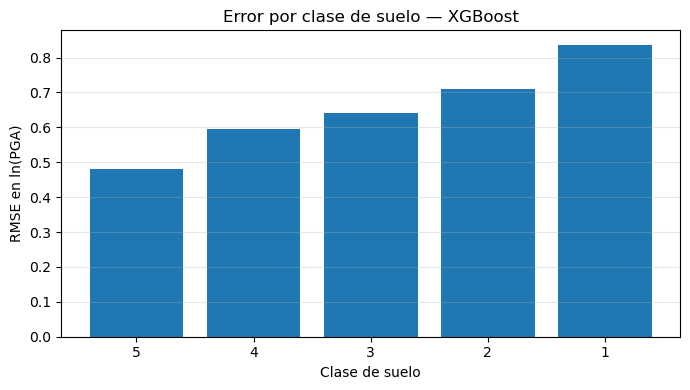

In [21]:
# =========================================================
# BLOQUE 21. MÉTRICAS POR CLASE DE SUELO
# =========================================================

test_results = X_test.copy()
test_results["y_true_log"] = y_test.values
test_results["y_pred_log"] = y_pred_best
test_results["residual_log"] = test_results["y_true_log"] - test_results["y_pred_log"]
test_results["y_true_g"] = np.exp(test_results["y_true_log"])
test_results["y_pred_g"] = np.exp(test_results["y_pred_log"])

soil_rows = []

for soil_class, group in test_results.groupby("Soil_Class"):

    if len(group) < 2:
        continue

    soil_rows.append({
        "Soil_Class": soil_class,
        "n_test": len(group),
        "RMSE_log": rmse(group["y_true_log"], group["y_pred_log"]),
        "MAE_log": mean_absolute_error(group["y_true_log"], group["y_pred_log"]),
        "R2_log": r2_score(group["y_true_log"], group["y_pred_log"]),
        "Bias_log": group["residual_log"].mean(),
        "SD_residual_log": group["residual_log"].std(ddof=1),
        "RMSE_g": rmse(group["y_true_g"], group["y_pred_g"]),
        "MAE_g": mean_absolute_error(group["y_true_g"], group["y_pred_g"]),
    })

soil_metrics_df = pd.DataFrame(soil_rows).sort_values("RMSE_log")

display(soil_metrics_df.round(4))

plt.figure(figsize=(7, 4))
plt.bar(soil_metrics_df["Soil_Class"].astype(str), soil_metrics_df["RMSE_log"])
plt.xlabel("Clase de suelo")
plt.ylabel("RMSE en ln(PGA)")
plt.title(f"Error por clase de suelo — {best_model_name}")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# =========================================================
# BLOQUE 26. CONCLUSIONES DEL CAPÍTULO
# =========================================================

second_best = comparison_df.iloc[1]

display(Markdown(f"""
## Conclusiones

En este capítulo se aplicaron modelos de Machine Learning para predecir `ln(PGA)`, usando como aproximación el periodo `T = {TARGET_PERIOD} s`.

El flujo siguió la misma estructura general del Dash, pero ajustando las transformaciones a la escala real del Jupyter Book.

### Decisiones de escala

En el Dash, `Rrup_OpenQuake` estaba en kilómetros. En este Jupyter Book, `Rrup_OpenQuake` ya viene como `ln(Rrup)`. Por eso, en este capítulo se usó:

- `Rrup_km = exp(Rrup_OpenQuake)`
- `log_Rrup = Rrup_OpenQuake`

De esta forma se evita aplicar logaritmo dos veces.

También se verificó que `{TARGET}` ya está en escala logarítmica, por lo que se modeló directamente como `ln(PGA)`.

### Modelos evaluados

Se entrenaron los cinco modelos del Dash:

1. Regresión lineal
2. XGBoost
3. Random Forest
4. SVR con kernel RBF
5. MLP

### Mejor modelo

El mejor modelo fue **{best_model_name}**, con:

- RMSE en ln(PGA): **{best_row["rmse"]:.4f}**
- MAE en ln(PGA): **{best_row["mae"]:.4f}**
- R² en test: **{best_row["r2"]:.4f}**
- R² CV5: **{best_row["r2_cv5"]:.4f}**
- Bias de residuos: **{best_row["bias_log"]:.4f}**
- Desviación estándar de residuos: **{best_row["sd_residual_log"]:.4f}**

El segundo mejor modelo fue **{second_best["display_name"]}**, con RMSE de **{second_best["rmse"]:.4f}**.

Bajo esta partición de entrenamiento y prueba, el modelo seleccionado para representar el mejor desempeño predictivo del capítulo es **{best_model_name}**.
"""))


## Conclusiones

En este capítulo se aplicaron modelos de Machine Learning para predecir `ln(PGA)`, usando como aproximación el periodo `T = 0.01 s`.

El flujo siguió la misma estructura general del Dash, pero ajustando las transformaciones a la escala real del Jupyter Book.

### Decisiones de escala

En el Dash, `Rrup_OpenQuake` estaba en kilómetros. En este Jupyter Book, `Rrup_OpenQuake` ya viene como `ln(Rrup)`. Por eso, en este capítulo se usó:

- `Rrup_km = exp(Rrup_OpenQuake)`
- `log_Rrup = Rrup_OpenQuake`

De esta forma se evita aplicar logaritmo dos veces.

También se verificó que `T_0.01_RotD50` ya está en escala logarítmica, por lo que se modeló directamente como `ln(PGA)`.

### Modelos evaluados

Se entrenaron los cinco modelos del Dash:

1. Regresión lineal
2. XGBoost
3. Random Forest
4. SVR con kernel RBF
5. MLP

### Mejor modelo

El mejor modelo fue **XGBoost**, con:

- RMSE en ln(PGA): **0.6414**
- MAE en ln(PGA): **0.4975**
- R² en test: **0.8583**
- R² CV5: **0.8579**
- Bias de residuos: **0.0092**
- Desviación estándar de residuos: **0.6415**

El segundo mejor modelo fue **Random Forest**, con RMSE de **0.6731**.

Bajo esta partición de entrenamiento y prueba, el modelo seleccionado para representar el mejor desempeño predictivo del capítulo es **XGBoost**.
